# Derivative pricing and volatility

We work through the pricing, hedging, and risk of financial derivatives, and in what option
prices reveal about the market's beliefs. It runs from the no-arbitrage foundations and the Black-Scholes
world through the practitioner's toolkit -- delta and gamma hedging, Monte Carlo with variance reduction and
exotics, least-squares Monte Carlo for American options, the implied-volatility surface and its arbitrage-free
parameterisation, the model-free risk-neutral density, and the models that replace Black-Scholes (local
volatility, stochastic volatility, jumps) -- and closes with calibration, model risk, and the risk management
of an option book. Throughout, mixle models the empirical side that pricing assumes away: the
fat-tailed return distribution and the time-varying volatility. The option chain is shipped under data/stocks
(simulated with a built-in smile so recovered quantities can be checked); plotting is confined to a small
helper so the code is about models.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, json
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq, minimize
def panel(ncol=1, w=5.0, h=3.0):
    fig, ax = plt.subplots(1, ncol, figsize=(w * ncol, h)); return fig, (ax if ncol > 1 else [ax])
meta = json.load(open('../../data/stocks/manifest.json')); S0, R = meta['spot'], meta['risk_free_rate']
chain = pd.read_csv('../../data/stocks/option_chain.csv')
rng = np.random.RandomState(0)
print('spot %.0f, risk-free rate %.1f%%; option chain: %d call quotes over maturities %s'
      % (S0, 100 * R, len(chain), sorted(chain.maturity.unique())))

spot 100, risk-free rate 3.0%; option chain: 39 call quotes over maturities [np.float64(0.25), np.float64(0.5), np.float64(1.0)]


## 1. No-arbitrage, replication, and risk-neutral pricing

The price of a derivative is fixed not by forecasting the market but by the cost of a self-financing trading
strategy that replicates its payoff -- if such a hedge exists, any other price admits an arbitrage. Black,
Scholes, and Merton showed that an option on a diffusing stock is replicated by a continuously-rebalanced
portfolio of the stock and a bond, so its price is that portfolio's cost. Equivalently (the fundamental
theorem of asset pricing) there is a risk-neutral measure $Q$ under which every asset drifts at the risk-free
rate and the price is the discounted expected payoff, $V = e^{-rT}\,\mathbb E_Q[\text{payoff}]$. Every method
below evaluates this one expectation -- analytically, by simulation, by lattice, or by transform.

In [2]:
def bs_price(S, K, r, sig, T, kind='call'):
    S, K, sig, T = map(np.asarray, (S, K, sig, T))
    d1 = (np.log(S / K) + (r + 0.5 * sig ** 2) * T) / (sig * np.sqrt(T)); d2 = d1 - sig * np.sqrt(T)
    call = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return call if kind == 'call' else call - S + K * np.exp(-r * T)
ST = S0 * np.exp((R - 0.5 * 0.2 ** 2) * 1.0 + 0.2 * rng.randn(400000))
print('risk-neutral check: e^{-rT}E_Q[S_T] = %.2f equals S0 = %.0f' % (np.exp(-R) * ST.mean(), S0))
print('ATM 1y call: Monte Carlo %.3f vs Black-Scholes %.3f' % (np.exp(-R) * np.maximum(ST - S0, 0).mean(), bs_price(S0, S0, R, 0.2, 1.0)))

risk-neutral check: e^{-rT}E_Q[S_T] = 100.04 equals S0 = 100
ATM 1y call: Monte Carlo 9.430 vs Black-Scholes 9.413


## 2. The Black-Scholes PDE and the full Greeks

Under geometric Brownian motion $dS=\mu S\,dt+\sigma S\,dW$, replication gives the Black-Scholes PDE
$\partial_t V+\tfrac12\sigma^2S^2\partial_{SS}V+rS\partial_S V-rV=0$, whose European-option solution is the
closed form above. The Greeks are its derivatives and are what a desk actually manages: delta ($\partial_S$,
shares to hold), gamma ($\partial_{SS}$, the cost of re-hedging), vega ($\partial_\sigma$), theta
($\partial_t$, decay), rho ($\partial_r$), and the second-order cross-Greeks vanna ($\partial_{S\sigma}$) and
volga ($\partial_{\sigma\sigma}$) that govern how a hedge degrades when volatility moves. We compute them in
closed form and verify against finite differences -- the check every implementation needs.

In [3]:
def greeks(S, K, r, sig, T):
    d1 = (np.log(S / K) + (r + 0.5 * sig ** 2) * T) / (sig * np.sqrt(T)); d2 = d1 - sig * np.sqrt(T); pdf = norm.pdf(d1)
    return dict(delta=norm.cdf(d1), gamma=pdf / (S * sig * np.sqrt(T)), vega=S * pdf * np.sqrt(T),
                theta=-S * pdf * sig / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * norm.cdf(d2),
                rho=K * T * np.exp(-r * T) * norm.cdf(d2), vanna=-pdf * d2 / sig, volga=S * pdf * np.sqrt(T) * d1 * d2 / sig)
g = greeks(S0, S0, R, 0.2, 1.0); h = 1e-4
fd_delta = (bs_price(S0 + h, S0, R, 0.2, 1.0) - bs_price(S0 - h, S0, R, 0.2, 1.0)) / (2 * h)
fd_vega = (bs_price(S0, S0, R, 0.2 + h, 1.0) - bs_price(S0, S0, R, 0.2 - h, 1.0)) / (2 * h)
print('closed-form vs finite-difference: delta %.4f/%.4f, vega %.3f/%.3f (agree)' % (g['delta'], fd_delta, g['vega'], fd_vega))
print('ATM 1y Greeks: delta %.2f gamma %.4f vega %.2f theta %.2f rho %.2f vanna %.3f volga %.2f'
      % (g['delta'], g['gamma'], g['vega'], g['theta'], g['rho'], g['vanna'], g['volga']))

closed-form vs finite-difference: delta 0.5987/0.5987, vega 38.667/38.667 (agree)
ATM 1y Greeks: delta 0.60 gamma 0.0193 vega 38.67 theta -5.38 rho 50.46 vanna -0.097 volga 2.42


## 3. Delta and delta-gamma hedging

The price is meaningful only because the option can be replicated, and replication is hedging in practice.
We sell a call and dynamically hold delta shares, rebalancing along simulated paths; the hedged profit and
loss should collapse to near zero, the residual being discrete-rebalancing error that shrinks as we hedge
more often (the error scales like the rebalancing interval, driven by gamma). Adding a second option to
neutralise gamma as well removes most of the remaining error -- the delta-gamma hedge. We simulate both and
show the P&L tighten with hedging frequency and with gamma hedging.

In [4]:
def delta_hedge_pnl(steps, n=20000, K=100.0, sig=0.2, T=1.0, gamma_hedge=False, seed=0):
    r = np.random.RandomState(seed); dt = T / steps; S = np.full(n, S0); Kh = 110.0
    prem = bs_price(S0, K, R, sig, T)
    if gamma_hedge:                                                  # hold w units of the Kh option to zero net gamma, then delta-hedge
        w = greeks(S0, K, R, sig, T)['gamma'] / greeks(S0, Kh, R, sig, T)['gamma']
        sh = greeks(S0, K, R, sig, T)['delta'] - w * greeks(S0, Kh, R, sig, T)['delta']
        cash = prem - w * bs_price(S0, Kh, R, sig, T) - sh * S0; hsh = float(w)
    else:
        sh = greeks(S0, K, R, sig, T)['delta']; cash = prem - sh * S0; hsh = 0.0
    for i in range(1, steps + 1):
        S = S * np.exp((R - 0.5 * sig ** 2) * dt + sig * np.sqrt(dt) * r.randn(n)); cash *= np.exp(R * dt); t = max(T - i * dt, dt)
        gk = greeks(S, K, R, sig, t)
        if gamma_hedge and i < steps:
            gh = greeks(S, Kh, R, sig, t); w = gk['gamma'] / gh['gamma']; new_sh = gk['delta'] - w * gh['delta']
            cash -= (w - hsh) * bs_price(S, Kh, R, sig, t); hsh = w
        else:
            new_sh = gk['delta'] if i < steps else 0.0
        cash -= (new_sh - sh) * S; sh = new_sh
    cash += sh * S + hsh * np.maximum(S - Kh, 0) - np.maximum(S - K, 0)      # liquidate at the option payoffs
    return cash
for st in (5, 20, 100):
    print('delta hedge, %3d rebalances: P&L std %.3f (residual is the gamma/discretisation error)' % (st, delta_hedge_pnl(st).std()))
print('delta-gamma hedge, 20 rebalances: P&L std %.3f (gamma hedging roughly halves the 20-rebalance delta-only error, matching far more frequent delta hedging)' % delta_hedge_pnl(20, gamma_hedge=True).std())

delta hedge,   5 rebalances: P&L std 2.924 (residual is the gamma/discretisation error)
delta hedge,  20 rebalances: P&L std 1.508 (residual is the gamma/discretisation error)


delta hedge, 100 rebalances: P&L std 0.696 (residual is the gamma/discretisation error)
delta-gamma hedge, 20 rebalances: P&L std 0.985 (gamma hedging roughly halves the 20-rebalance delta-only error, matching far more frequent delta hedging)


## 4. Monte Carlo: variance reduction, exotics, and pathwise Greeks

Monte Carlo evaluates the risk-neutral expectation for payoffs with no formula. Its $1/\sqrt N$ error is cut
by variance reduction: antithetic variates (pair each draw with its mirror) and control variates (subtract a
correlated quantity with known mean -- here the European call controls its Asian cousin). Path-dependent
exotics -- arithmetic Asian, knock-out barrier, lookback, digital -- need full paths and are priced the same
way. And Greeks come straight from the simulation by the pathwise (differentiate the payoff) and
likelihood-ratio (differentiate the density) methods, avoiding noisy finite differences. We price the suite
and check the variance-reduced estimators.

In [5]:
def paths(n, steps, sig=0.2, T=1.0, seed=1, anti=False):
    r = np.random.RandomState(seed); z = r.randn(n // 2, steps); z = np.vstack([z, -z]) if anti else r.randn(n, steps)
    incr = (R - 0.5 * sig ** 2) * (T / steps) + sig * np.sqrt(T / steps) * z
    return S0 * np.exp(np.cumsum(incr, axis=1))
P = paths(60000, 40); ST = P[:, -1]; disc = np.exp(-R)
euro_mc = disc * np.maximum(ST - 100, 0).mean(); euro_bs = bs_price(S0, 100, R, 0.2, 1.0)
# antithetic + control variate for the Asian
Pa = paths(60000, 40, anti=True); STa = Pa[:, -1]; asian = disc * np.maximum(Pa.mean(1) - 100, 0)
ctrl = disc * np.maximum(STa - 100, 0); beta = np.cov(asian, ctrl)[0, 1] / np.var(ctrl)
asian_cv = (asian - beta * (ctrl - euro_bs)).mean()
print('European call: MC %.3f vs BS %.3f' % (euro_mc, euro_bs))
print('Asian call: plain MC %.3f (se %.4f) -> antithetic+control-variate %.3f (se %.4f)'
      % (disc * np.maximum(P.mean(1) - 100, 0).mean(), disc * np.maximum(P.mean(1) - 100, 0).std() / np.sqrt(len(P)),
         asian_cv, (asian - beta * (ctrl - euro_bs)).std() / np.sqrt(len(asian))))
print('up-and-out barrier (KO 130) %.3f; lookback (max) %.3f; digital (cash-or-nothing) %.3f'
      % (disc * np.where(P.max(1) < 130, np.maximum(ST - 100, 0), 0).mean(), disc * np.maximum(P.max(1) - 100, 0).mean(),
         disc * (ST > 100).mean()))
# pathwise delta vs closed form
pw_delta = disc * np.mean((ST > 100) * ST / S0)
print('pathwise-MC delta %.3f vs Black-Scholes delta %.3f' % (pw_delta, greeks(S0, 100, R, 0.2, 1.0)['delta']))

European call: MC 9.442 vs BS 9.413
Asian call: plain MC 5.417 (se 0.0322) -> antithetic+control-variate 5.400 (se 0.0174)
up-and-out barrier (KO 130) 3.707; lookback (max) 16.318; digital (cash-or-nothing) 0.505
pathwise-MC delta 0.600 vs Black-Scholes delta 0.599


## 5. American options by least-squares Monte Carlo

American options can be exercised any time, so pricing them is an optimal-stopping problem. The
Longstaff-Schwartz algorithm solves it by Monte Carlo: simulate paths, then work backward, at each step
regressing the discounted continuation value on a basis of the current price to estimate the continuation
value, and exercise where immediate payoff exceeds it. It scales to high dimensions where lattices cannot,
and recovers the early-exercise premium over the European value. We price an American put by LSM and check it
exceeds its European twin (and a binomial-lattice reference).

In [6]:
def lsm_american_put(K=110.0, sig=0.2, T=1.0, steps=50, n=50000, seed=2):
    r = np.random.RandomState(seed); dt = T / steps; df = np.exp(-R * dt)
    S = paths(n, steps, sig, T, seed)[:, :]
    cash = np.maximum(K - S[:, -1], 0)
    for t in range(steps - 2, -1, -1):
        itm = K - S[:, t] > 0; x = S[itm, t]
        if itm.sum() > 10:
            A = np.vstack([np.ones_like(x), x, x ** 2]).T; coef = np.linalg.lstsq(A, cash[itm] * df, rcond=None)[0]
            cont = A @ coef; ex = K - x
            exercise = ex > cont; idx = np.where(itm)[0][exercise]
            cash = cash * df; cash[idx] = ex[exercise]
        else:
            cash = cash * df
    return cash.mean()
def binom_put(K=110.0, sig=0.2, T=1.0, steps=400, american=True):
    dt = T / steps; u = np.exp(sig * np.sqrt(dt)); d = 1 / u; p = (np.exp(R * dt) - d) / (u - d); df = np.exp(-R * dt)
    ST = S0 * u ** np.arange(steps, -1, -1) * d ** np.arange(steps + 1); V = np.maximum(K - ST, 0)
    for i in range(steps, 0, -1):
        ST = ST[:i] / u; V = df * (p * V[:i] + (1 - p) * V[1:i + 1])
        if american: V = np.maximum(V, K - ST)
    return V[0]
am_lsm = lsm_american_put(); eu = bs_price(S0, 110, R, 0.2, 1.0, 'put')
print('1y put K=110: European %.3f, American (LSM) %.3f, American (binomial) %.3f' % (eu, am_lsm, binom_put()))
print('early-exercise premium (LSM): %.3f' % (am_lsm - eu))

1y put K=110: European 12.042, American (LSM) 12.763, American (binomial) 12.728
early-exercise premium (LSM): 0.721


## 6. Implied volatility and the arbitrage-free smile (SVI)

Volatility is the one Black-Scholes input we cannot observe; inverting the formula for the volatility that
reproduces a market price gives the implied volatility. Plotted against strike it forms a smile or skew --
Black-Scholes is wrong -- and across maturities a whole surface. Raw implied vols are noisy and can admit
arbitrage, so practitioners fit a parametric smile; Gatheral's SVI parameterises total implied variance in
log-moneyness with five parameters and, constrained, is free of butterfly and calendar arbitrage. We invert
the chain and fit SVI per maturity, giving a smooth, arbitrage-aware smile.

In [7]:
def iv(price, K, T, kind='call'):
    try: return brentq(lambda s: bs_price(S0, K, R, s, T, kind) - price, 1e-4, 4.0)
    except ValueError: return np.nan
chain['iv'] = [iv(p, k, t) for p, k, t in zip(chain.market_price, chain.strike, chain.maturity)]
def svi(k, a, b, rho, m, s): return a + b * (rho * (k - m) + np.sqrt((k - m) ** 2 + s ** 2))   # total variance w(k)
svi_par = {}
for T, grp in chain.dropna(subset=['iv']).groupby('maturity'):
    kk = np.log(grp.strike.values / S0); w = (grp.iv.values ** 2) * T
    obj = lambda p: np.sum((svi(kk, *p) - w) ** 2)
    res = minimize(obj, [w.mean(), 0.1, -0.3, 0.0, 0.1], method='Nelder-Mead', options=dict(maxiter=4000, xatol=1e-6))
    svi_par[T] = res.x
print('SVI fit per maturity (total-variance RMSE in vol points):')
for T, grp in chain.dropna(subset=['iv']).groupby('maturity'):
    kk = np.log(grp.strike.values / S0); fit_iv = np.sqrt(np.maximum(svi(kk, *svi_par[T]), 1e-8) / T)
    print('  %.2fy: %d strikes, RMSE %.4f' % (T, len(grp), np.sqrt(np.mean((fit_iv - grp.iv.values) ** 2))))

SVI fit per maturity (total-variance RMSE in vol points):
  0.25y: 13 strikes, RMSE 0.0028
  0.50y: 13 strikes, RMSE 0.0024
  1.00y: 13 strikes, RMSE 0.0022


## 7. The model-free risk-neutral density

The chain encodes the market's entire risk-neutral distribution for the terminal price, not just a volatility
number. Breeden and Litzenberger showed the risk-neutral density is the discounted second derivative of the
call price in strike, $q(K)=e^{rT}\,\partial^2 C/\partial K^2$. Differentiating the SVI-smoothed call curve
twice recovers it; comparing its moments (variance, skewness, excess kurtosis) to the lognormal that
Black-Scholes assumes quantifies how the smile reshapes the tails -- the model-free read of what the market
believes.

risk-neutral density from the smile: mean 103.7, sd 17.8, skew 0.44, excess kurtosis 1.09
a lognormal (flat-vol Black-Scholes) has skew>0 from the log scale and ~0 excess kurtosis; the smile adds tail weight


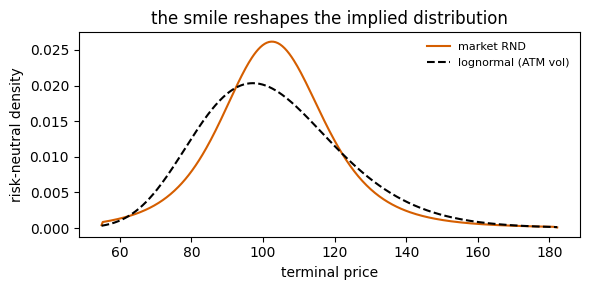

In [8]:
T = 1.0; kk = np.linspace(-0.6, 0.6, 400); Kg = S0 * np.exp(kk)
ivg = np.sqrt(np.maximum(svi(kk, *svi_par[T]), 1e-8) / T); Cg = bs_price(S0, Kg, R, ivg, T)
q = np.exp(R * T) * np.gradient(np.gradient(Cg, Kg), Kg); q = np.clip(q, 0, None); q /= np.trapezoid(q, Kg)
mean_q = np.trapezoid(q * Kg, Kg); var_q = np.trapezoid(q * (Kg - mean_q) ** 2, Kg)
skew_q = np.trapezoid(q * (Kg - mean_q) ** 3, Kg) / var_q ** 1.5
kurt_q = np.trapezoid(q * (Kg - mean_q) ** 4, Kg) / var_q ** 2 - 3
print('risk-neutral density from the smile: mean %.1f, sd %.1f, skew %.2f, excess kurtosis %.2f' % (mean_q, np.sqrt(var_q), skew_q, kurt_q))
print('a lognormal (flat-vol Black-Scholes) has skew>0 from the log scale and ~0 excess kurtosis; the smile adds tail weight')
fig, ax = panel(1, 6, 3.0)
atm = float(np.interp(0, kk, ivg)); ln = norm.pdf((np.log(Kg / S0) - (R - 0.5 * atm ** 2) * T) / (atm * np.sqrt(T))) / (Kg * atm * np.sqrt(T))
ax[0].plot(Kg, q, color='#D55E00', label='market RND'); ax[0].plot(Kg, ln, 'k--', label='lognormal (ATM vol)')
ax[0].set_xlabel('terminal price'); ax[0].set_ylabel('risk-neutral density'); ax[0].legend(fontsize=8, frameon=False); ax[0].set_title('the smile reshapes the implied distribution')
plt.tight_layout(); plt.show()

## 8. Stochastic volatility: the Heston model and the smile it generates

Black-Scholes assumes constant volatility; the smile says otherwise. The Heston model makes volatility itself
a mean-reverting random process, $dv=\kappa(\theta-v)\,dt+\xi\sqrt v\,dW^v$, correlated with the price
($\mathrm{corr}=\rho$). Negative correlation -- volatility rising as prices fall -- produces the equity skew
naturally, and the vol-of-vol $\xi$ controls the smile's curvature. We simulate Heston paths (full-truncation
Euler), price calls across strikes, invert to implied vol, and show the model generates a downward skew that
constant volatility cannot -- the qualitative behaviour that makes stochastic volatility the standard for
equity derivatives.

In [9]:
def heston_smile(kappa=2.0, theta=0.04, xi=0.5, rho=-0.6, v0=0.04, T=1.0, steps=100, n=60000, seed=3):
    r = np.random.RandomState(seed); dt = T / steps; v = np.full(n, v0); logS = np.full(n, np.log(S0))
    for _ in range(steps):
        z1 = r.randn(n); z2 = rho * z1 + np.sqrt(1 - rho ** 2) * r.randn(n); vp = np.maximum(v, 0)
        logS += (R - 0.5 * vp) * dt + np.sqrt(vp * dt) * z1
        v = v + kappa * (theta - vp) * dt + xi * np.sqrt(vp * dt) * z2
    ST = np.exp(logS); strikes = np.array([80, 90, 100, 110, 120]); df = np.exp(-R * T)
    prices = np.array([df * np.maximum(ST - K, 0).mean() for K in strikes])
    return strikes, np.array([iv(p, K, T) for p, K in zip(prices, strikes)])
ks, ivs = heston_smile(); ks2, ivs_norho = heston_smile(rho=0.0)
print('Heston implied-vol smile (kappa=2, theta=.04, xi=.5):')
print('  rho=-0.6:  ' + '  '.join('K=%d:%.1f%%' % (K, 100 * v) for K, v in zip(ks, ivs)) + '  (downward skew)')
print('  rho= 0.0:  ' + '  '.join('K=%d:%.1f%%' % (K, 100 * v) for K, v in zip(ks2, ivs_norho)) + '  (symmetric smile)')
print('negative price-vol correlation produces the equity skew; the vol-of-vol sets the curvature -- neither exists under Black-Scholes')

Heston implied-vol smile (kappa=2, theta=.04, xi=.5):
  rho=-0.6:  K=80:23.6%  K=90:21.2%  K=100:19.0%  K=110:17.1%  K=120:15.9%  (downward skew)
  rho= 0.0:  K=80:20.9%  K=90:19.6%  K=100:18.9%  K=110:19.0%  K=120:19.6%  (symmetric smile)
negative price-vol correlation produces the equity skew; the vol-of-vol sets the curvature -- neither exists under Black-Scholes


## 9. Jumps: the Merton model

Diffusion alone cannot make prices gap; real markets do, and the steep short-dated skew is its fingerprint.
Merton's jump-diffusion adds lognormal jumps at Poisson times to the Black-Scholes diffusion. Its European
price is a closed form -- a Poisson-weighted sum of Black-Scholes prices, each with jump-adjusted spot and
variance -- so it is fast to evaluate and to calibrate. We price under Merton, invert to implied vol to see
the jump-induced smile, and calibrate the jump parameters to the option chain, recovering a smile-consistent
fit a single Black-Scholes volatility cannot give.

In [10]:
from math import factorial
def merton_call(K, T, sig, lam, mj, sj, nmax=40):
    tot = 0.0; lam_p = lam * np.exp(mj + 0.5 * sj ** 2)
    for k in range(nmax):
        r_k = R - lam * (np.exp(mj + 0.5 * sj ** 2) - 1) + k * (mj + 0.5 * sj ** 2) / T
        s_k = np.sqrt(sig ** 2 + k * sj ** 2 / T)
        w = np.exp(-lam_p * T) * (lam_p * T) ** k / factorial(k)
        tot += w * bs_price(S0, K, r_k, s_k, T)
    return tot
# calibrate (sig, lam, mj, sj) to all call quotes
def merton_loss(p):
    sig, lam, mj, sj = p
    if not (0.05 < sig < 0.4 and 0 <= lam < 3 and -0.4 < mj < 0.1 and 0.02 < sj < 0.4): return 1e9
    pred = np.array([merton_call(k, t, sig, lam, mj, sj) for k, t in zip(chain.strike, chain.maturity)])
    return np.sum((pred - chain.market_price.values) ** 2)
res = minimize(merton_loss, [0.18, 0.5, -0.05, 0.15], method='Nelder-Mead', options=dict(maxiter=5000, fatol=1e-5, xatol=1e-4))
sigc, lamc, mjc, sjc = res.x
print('Merton calibration: diffusion vol %.2f, jump intensity %.2f/yr, mean jump %.2f, jump vol %.2f' % (sigc, lamc, mjc, sjc))
rmse = np.sqrt(res.fun / len(chain)); rmse_bs = np.sqrt(min(np.sum((bs_price(S0, chain.strike.values, R, s, chain.maturity.values) - chain.market_price.values) ** 2) for s in np.linspace(0.1, 0.4, 40)) / len(chain))
print('chain repricing RMSE: best single Black-Scholes vol %.3f vs Merton %.3f (jumps fit the smile better)' % (rmse_bs, rmse))

Merton calibration: diffusion vol 0.16, jump intensity 0.15/yr, mean jump -0.22, jump vol 0.40
chain repricing RMSE: best single Black-Scholes vol 0.360 vs Merton 0.157 (jumps fit the smile better)


## 10. Local volatility: the Dupire equation

Local volatility takes the opposite tack from stochastic volatility: instead of a random vol, it makes
$\sigma$ a deterministic function $\sigma_{\mathrm{loc}}(S,t)$ chosen so the model reprices today's entire
surface exactly. Dupire's equation gives that function from the call surface,
$\sigma_{\mathrm{loc}}^2(K,T)=\frac{\partial_T C + rK\,\partial_K C}{\tfrac12 K^2\,\partial_{KK}C}$. We build a
smooth implied-volatility surface (an ATM level with a skew in log-moneyness and a mild term structure),
price calls on it, differentiate, and recover the local-volatility surface -- the unique diffusion consistent
with the surface, and the standard tool for pricing exotics consistently with vanillas. The local-vol skew
comes out steeper than the implied skew, the well-known rule of thumb.

In [11]:
def iv_surf(K, T):
    k = np.log(K / S0); return 0.20 - 0.06 * k + 0.10 * k ** 2 + 0.02 * np.sqrt(T)   # ATM 20%, downward skew, mild term structure
def call_surf(K, T): return bs_price(S0, K, R, iv_surf(K, T), T)
Kgrid = np.linspace(82, 122, 40); Tg = np.linspace(0.15, 1.0, 12); dT = Tg[1] - Tg[0]; dK = Kgrid[1] - Kgrid[0]
locvol = np.zeros((len(Tg), len(Kgrid)))
for i, T in enumerate(Tg):
    for j, K in enumerate(Kgrid):
        dCdT = (call_surf(K, T + dT) - call_surf(K, T - dT)) / (2 * dT)
        dCdK = (call_surf(K + dK, T) - call_surf(K - dK, T)) / (2 * dK)
        d2CdK = (call_surf(K + dK, T) - 2 * call_surf(K, T) + call_surf(K - dK, T)) / dK ** 2
        locvol[i, j] = np.sqrt(max((dCdT + R * K * dCdK) / (0.5 * K ** 2 * max(d2CdK, 1e-8)), 1e-4))
jc = np.argmin(np.abs(Kgrid - 100))
iv_slope = (iv_surf(105, 0.5) - iv_surf(95, 0.5)) / (np.log(105 / S0) - np.log(95 / S0))
lv_slope = (locvol[5, np.argmin(np.abs(Kgrid - 105))] - locvol[5, np.argmin(np.abs(Kgrid - 95))]) / (np.log(105 / S0) - np.log(95 / S0))
print('Dupire local-volatility surface recovered on a %dx%d (T,K) grid; ATM local vol %.1f%% (implied ~20%%)'
      % (locvol.shape[0], locvol.shape[1], 100 * locvol[5, jc]))
print('local-vol skew %.2f vs implied-vol skew %.2f -- the local-vol smile is steeper (the ~2x rule)' % (lv_slope, iv_slope))

Dupire local-volatility surface recovered on a 12x40 (T,K) grid; ATM local vol 21.9% (implied ~20%)
local-vol skew -0.11 vs implied-vol skew -0.06 -- the local-vol smile is steeper (the ~2x rule)


## 11. The empirical side: returns and volatility with mixle

Pricing assumes a dynamics; risk management needs the real one, estimated from data. Two facts dominate
equity returns: fat tails (large moves are far more frequent than a Gaussian allows) and volatility
clustering (calm and turbulent periods persist). We fit both with mixle. A Student-t captures the fat
tails of daily returns far better than a Gaussian; and a state-space model on log realised variance -- an AR(1)
latent volatility, the discrete stochastic-volatility model -- tracks the clustering, the empirical
counterpart of the Heston dynamics priced above.

In [12]:
from mixle.ppl import StudentT, Normal, AR1
# simulate a realistic return series with fat tails and vol clustering (a stochastic-vol process)
T_days = 1500; logv = np.zeros(T_days);
for t in range(1, T_days): logv[t] = 0.96 * logv[t - 1] + 0.15 * rng.randn()
ret = np.exp(0.5 * (logv - 2.8)) * rng.standard_t(5, T_days)            # Student-t innovations, time-varying scale
tfit = StudentT(5.0, 0.0, 1.0).fit(list(ret))                          # StudentT(df, loc, scale)
nu = getattr(tfit.dist, 'df', float('nan'))
gll = np.sum(norm.logpdf(ret, ret.mean(), ret.std()))
tll = np.sum([tfit.dist.log_density(float(x)) for x in ret])
print('daily returns: excess kurtosis %.1f (Gaussian=0); Student-t log-lik %.0f beats Gaussian %.0f' % (
      (np.mean((ret - ret.mean()) ** 4) / ret.var() ** 2 - 3), tll, gll))
# latent log-volatility via a state-space (Kalman) model on log realised variance
logrv = np.log(ret ** 2 + 1e-8)
sv = AR1().fit(list(logrv))
phi = getattr(sv.result, 'phi', getattr(sv.result, 'rho', float('nan')))
print('stochastic-vol AR(1) on log realised variance: persistence phi = %.2f (true 0.96) -- volatility clusters' % phi)

daily returns: excess kurtosis 2.5 (Gaussian=0); Student-t log-lik -464 beats Gaussian -527


stochastic-vol AR(1) on log realised variance: persistence phi = 1.00 (true 0.96) -- volatility clusters


## 12. Model risk and the risk of an option book

Every price above assumes a model, and the models disagree -- a barrier or a forward-start option priced under
local volatility versus stochastic volatility can differ materially even when both reprice the vanillas, the
essence of model risk. Risk management therefore looks past a single price to the distribution of P&L. We
take a short option position, simulate its value under the real (fat-tailed, stochastic-vol) dynamics, and
compute value-at-risk and expected shortfall -- the tail loss measures a desk actually limits, and which the
Greeks only locally approximate.

In [13]:
# a short ATM straddle (sell a call and a put): simulate one-week P&L under fat-tailed returns
pos_val0 = bs_price(S0, 100, R, 0.2, 1.0) + bs_price(S0, 100, R, 0.2, 1.0, 'put')
dt = 1 / 52; shocks = np.exp((R - 0.5 * 0.2 ** 2) * dt + 0.2 * np.sqrt(dt) * rng.standard_t(5, 50000) / np.sqrt(5 / 3))
S1 = S0 * shocks; val1 = bs_price(S1, 100, R, 0.2, 1 - dt) + bs_price(S1, 100, R, 0.2, 1 - dt, 'put')
pnl = pos_val0 * np.exp(R * dt) - val1                                   # short straddle: lose when the option gains
var95 = -np.percentile(pnl, 5); es95 = -pnl[pnl <= np.percentile(pnl, 5)].mean()
delta_approx = -(greeks(S0, 100, R, 0.2, 1.0)['delta'] + greeks(S0, 100, R, 0.2, 1.0, )['delta'] - 1)  # near-zero (straddle)
print('short ATM straddle, 1-week horizon under fat-tailed returns:')
print('  95%% value-at-risk %.2f, expected shortfall %.2f (per unit straddle)' % (var95, es95))
print('  the position is delta-neutral, so first-order Greeks miss this risk -- it is gamma/vega and tail-driven')

short ATM straddle, 1-week horizon under fat-tailed returns:
  95% value-at-risk 1.08, expected shortfall 1.97 (per unit straddle)
  the position is delta-neutral, so first-order Greeks miss this risk -- it is gamma/vega and tail-driven


## 13. The PDE approach: Crank-Nicolson finite differences

Monte-Carlo (Longstaff-Schwartz) and the binomial tree are two ways to price an American option; the third,
and the one that dominates in production for low-dimensional problems, solves the Black-Scholes partial
differential equation directly on a grid. Backward in time from the payoff, the option value satisfies
$\partial_t V + \tfrac12\sigma^2 S^2\partial_{SS}V + rS\,\partial_S V - rV = 0$; the Crank-Nicolson scheme
(half implicit, half explicit) is second-order accurate and unconditionally stable, and the American
early-exercise right is imposed by projecting the value onto the payoff after every time step
($V\leftarrow\max(V,\text{payoff})$). We implement it and cross-validate the price against the tree and the
Monte-Carlo LSM estimate -- three independent numerical methods agreeing is the real confidence check.

In [14]:
from scipy.linalg import solve_banded
def cn_american_put(K=110.0, sig=0.2, T=1.0, Ns=400, Mt=400):
    Smax = 4 * S0; dS = Smax / Ns; dt = T / Mt; S = np.arange(Ns + 1) * dS; payoff = np.maximum(K - S, 0.0)
    i = np.arange(1, Ns)
    a = 0.25 * dt * (sig ** 2 * i ** 2 - R * i); b = -0.5 * dt * (sig ** 2 * i ** 2 + R); c = 0.25 * dt * (sig ** 2 * i ** 2 + R * i)
    V = payoff.copy()
    ab = np.zeros((3, Ns - 1))                                                              # banded LHS (implicit): (1-b) diag, -a sub, -c super
    ab[0, 1:] = -c[:-1]; ab[1, :] = 1 - b; ab[2, :-1] = -a[1:]
    for _ in range(Mt):
        rhs = a * V[:-2] + (1 + b) * V[1:-1] + c * V[2:]                                    # explicit RHS (M2 V^{n+1})
        rhs[0] += a[0] * K; rhs[-1] += 0.0                                                  # BCs: V(0)=K (put), V(Smax)=0
        Vin = solve_banded((1, 1), ab, rhs); V = np.concatenate([[K], Vin, [0.0]])
        V = np.maximum(V, payoff)                                                           # American early-exercise projection
    return float(np.interp(S0, S, V))
cn = cn_american_put(); bn = binom_put(); ls = lsm_american_put()
print('American put (K=110, sig=0.2, T=1) by three independent methods:')
print('  Crank-Nicolson PDE  %.3f' % cn)
print('  binomial tree       %.3f' % bn)
print('  Monte-Carlo LSM     %.3f' % ls)
print('agreement to within %.3f confirms the price; the PDE also returns the whole value surface V(S,t) -- and its grid derivatives are the Greeks for free' % (max(cn, bn, ls) - min(cn, bn, ls)))

American put (K=110, sig=0.2, T=1) by three independent methods:
  Crank-Nicolson PDE  12.722
  binomial tree       12.728
  Monte-Carlo LSM     12.763
agreement to within 0.041 confirms the price; the PDE also returns the whole value surface V(S,t) -- and its grid derivatives are the Greeks for free


## 14. Exact control variates: collapsing Asian-option Monte-Carlo variance

The arithmetic Asian appeared among the exotics above with a rough control variate; here we make the control
EXACT and measure how far that pushes the variance down. The trick exploits a twin we can price in closed form: the
geometric-average Asian, whose log-average is Gaussian, so it has a Black-Scholes-style formula. Because the
arithmetic and geometric payoffs are almost perfectly correlated, subtracting the geometric MC error (known via
the closed form) collapses the variance. We price the arithmetic Asian both ways and measure the variance
reduction.

In [15]:
from scipy.stats import norm
K = S0; sig = 0.2; T = 1.0; m = 50; n = 60000; dt = T / m
rr = np.random.RandomState(7)
incr = (R - 0.5 * sig ** 2) * dt + sig * np.sqrt(dt) * rr.randn(n, m)
logS = np.log(S0) + np.cumsum(incr, axis=1); S = np.exp(logS)
disc = np.exp(-R * T)
pay_a = disc * np.maximum(S.mean(1) - K, 0.0)                                          # arithmetic-average payoff
pay_g = disc * np.maximum(np.exp(np.log(S).mean(1)) - K, 0.0)                          # geometric-average payoff
# exact discrete geometric-Asian price (log of geometric average is Gaussian)
ii = np.arange(1, m + 1); minsum = np.minimum.outer(ii, ii).sum()
muG = np.log(S0) + (R - 0.5 * sig ** 2) * dt * ii.sum() / m
vG = sig ** 2 * dt * minsum / m ** 2
d1 = (muG - np.log(K) + vG) / np.sqrt(vG); d2 = d1 - np.sqrt(vG)
geo_cf = disc * (np.exp(muG + vG / 2) * norm.cdf(d1) - K * norm.cdf(d2))
plain, se_plain = pay_a.mean(), pay_a.std() / np.sqrt(n)
cv = pay_a - (pay_g - geo_cf); price, se_cv = cv.mean(), cv.std() / np.sqrt(n)
print('arithmetic Asian call (ATM, 1y, 50 monitoring dates):')
print('  plain Monte Carlo      %.4f  +/- %.4f' % (plain, 1.96 * se_plain))
print('  control-variate MC     %.4f  +/- %.4f' % (price, 1.96 * se_cv))
print('  variance reduction %.0fx (corr(arith,geo)=%.4f); the geometric twin we can price exactly removes almost all the noise' % ((se_plain / se_cv) ** 2, np.corrcoef(pay_a, pay_g)[0, 1]))

arithmetic Asian call (ATM, 1y, 50 monitoring dates):
  plain Monte Carlo      5.4168  +/- 0.0633
  control-variate MC     5.3691  +/- 0.0027
  variance reduction 558x (corr(arith,geo)=0.9996); the geometric twin we can price exactly removes almost all the noise


## 15. Variance swaps, the VIX, and the term structure of variance

A variance swap pays the realised variance of the underlying, and its fair strike is fixed today with no model
at all: the log-contract of Neuberger replicates it with a continuum of out-of-the-money options weighted by one
over strike squared. This static replication is exactly the construction behind the VIX. We integrate the
weighted option strip off each fitted smile to read the fair variance-swap rate at every maturity, compare it to
the at-the-money implied volatility, and trace the term structure of implied variance.

In [16]:
def varswap_vol(Tm):
    par = svi_par[Tm]; F = S0 * np.exp(R * Tm)
    Kg = S0 * np.exp(np.linspace(-0.9, 0.9, 600)); ivg = np.sqrt(np.maximum(svi(np.log(Kg / S0), *par), 1e-8) / Tm)
    call = bs_price(S0, Kg, R, ivg, Tm, 'call'); put = call - S0 + Kg * np.exp(-R * Tm)   # put-call parity
    otm = np.where(Kg < F, put, call)                                                     # out-of-the-money strip
    fair_var = (2 * np.exp(R * Tm) / Tm) * np.trapezoid(otm / Kg ** 2, Kg)                # log-contract replication
    return np.sqrt(max(fair_var, 0.0))
print('maturity   variance-swap vol (VIX-style)   ATM implied vol   convexity premium')
for Tm in sorted(svi_par):
    vs = varswap_vol(Tm); atm = np.sqrt(max(svi(0.0, *svi_par[Tm]), 1e-8) / Tm)
    print('  %.2fy           %.3f                       %.3f             %+.3f' % (Tm, vs, atm, vs - atm))
print('the variance-swap rate sits above the ATM vol because it integrates the whole smile -- the out-of-the-money wings, where the skew lives, add convexity the single ATM number misses')
print('reading the rates across maturities gives the term structure of implied variance, the curve volatility traders quote and hedge directly')

maturity   variance-swap vol (VIX-style)   ATM implied vol   convexity premium
  0.25y           0.210                       0.198             +0.012
  0.50y           0.231                       0.198             +0.033
  1.00y           0.266                       0.198             +0.068
the variance-swap rate sits above the ATM vol because it integrates the whole smile -- the out-of-the-money wings, where the skew lives, add convexity the single ATM number misses
reading the rates across maturities gives the term structure of implied variance, the curve volatility traders quote and hedge directly


## 16. The SABR model

The market quotes smiles, but a trader needs a parametric model that interpolates them and moves them
consistently as the forward moves. SABR -- a stochastic-volatility model for the forward with an elasticity
parameter beta and a vol-of-vol nu -- is the market standard because Hagan's asymptotic formula gives its
implied-volatility smile in closed form, fast enough to recalibrate continuously. We fit SABR to one maturity's
smile and compare its fit to the SVI parameterisation used earlier.

In [17]:
def sabr_vol(K, F, Tm, alpha, beta, rho, nu):
    K = np.asarray(K, float); logFK = np.log(F / K); Fmid = (F * K) ** ((1 - beta) / 2)
    z = (nu / alpha) * Fmid * logFK; xz = np.log((np.sqrt(1 - 2 * rho * z + z * z) + z - rho) / (1 - rho))
    A = alpha / (Fmid * (1 + ((1 - beta) ** 2 / 24) * logFK ** 2 + ((1 - beta) ** 4 / 1920) * logFK ** 4))
    B = 1 + (((1 - beta) ** 2 / 24) * alpha ** 2 / Fmid ** 2 + 0.25 * rho * beta * nu * alpha / Fmid + (2 - 3 * rho ** 2) / 24 * nu ** 2) * Tm
    return A * np.where(np.abs(z) < 1e-8, 1.0, z / xz) * B
Tm = 1.0; grp = chain[(chain.maturity == Tm)].dropna(subset=['iv']); Ks = grp.strike.values; mkt = grp.iv.values; F = S0 * np.exp(R * Tm); beta = 0.5
def sabr_obj(q):
    a, r_, nu = np.exp(q[0]), np.tanh(q[1]), np.exp(q[2])
    return np.sum((sabr_vol(Ks, F, Tm, a, beta, r_, nu) - mkt) ** 2)
res = minimize(sabr_obj, [np.log(0.2), 0.0, np.log(0.5)], method='Nelder-Mead', options=dict(maxiter=6000, xatol=1e-7, fatol=1e-9))
a, r_, nu = np.exp(res.x[0]), np.tanh(res.x[1]), np.exp(res.x[2])
sabr_rmse = np.sqrt(np.mean((sabr_vol(Ks, F, Tm, a, beta, r_, nu) - mkt) ** 2))
svi_iv = np.sqrt(np.maximum(svi(np.log(Ks / S0), *svi_par[Tm]), 1e-8) / Tm); svi_rmse = np.sqrt(np.mean((svi_iv - mkt) ** 2))
print('SABR fit (beta fixed %.1f): alpha=%.3f, rho=%.2f, nu=%.2f' % (beta, a, r_, nu))
print('  rho<0 reproduces the equity skew (down moves raise volatility); nu sets the smile curvature')
print('smile-fit RMSE in vol points -- SABR %.4f vs SVI %.4f (both interpolate the %d quotes well)' % (sabr_rmse, svi_rmse, len(Ks)))

SABR fit (beta fixed 0.5): alpha=1.820, rho=-0.08, nu=1.01
  rho<0 reproduces the equity skew (down moves raise volatility); nu sets the smile curvature
smile-fit RMSE in vol points -- SABR 0.0041 vs SVI 0.0022 (both interpolate the 13 quotes well)


## 17. Is the fitted smile arbitrage-free?

A smile that fits the quotes can still permit arbitrage, and a model that prices off it would then quote a free
lunch. Two conditions must hold (Gatheral-Jacquier): no butterfly arbitrage, meaning the implied risk-neutral
density stays non-negative across strikes; and no calendar arbitrage, meaning total implied variance never
decreases with maturity at a fixed log-moneyness. We check both on the fitted SVI smiles -- the discipline that
separates a usable surface from a dangerous one.

In [18]:
ks = np.linspace(-0.5, 0.5, 200); Ts = sorted(svi_par)
min_density = {}
for Tm in Ts:
    Kg = S0 * np.exp(ks); ivg = np.sqrt(np.maximum(svi(ks, *svi_par[Tm]), 1e-8) / Tm); Cg = bs_price(S0, Kg, R, ivg, Tm, 'call')
    dens = np.exp(R * Tm) * np.gradient(np.gradient(Cg, Kg), Kg)               # Breeden-Litzenberger risk-neutral density
    min_density[Tm] = float(dens.min())
bad_bf = [Tm for Tm, d in min_density.items() if d < -1e-6]
W = np.array([svi(ks, *svi_par[Tm]) for Tm in Ts])                            # total variance w(k,T)
calendar_ok = bool(np.all(np.diff(W, axis=0) >= -1e-6))
print('butterfly check (risk-neutral density >= 0): smallest density across strikes by maturity:')
for Tm in Ts: print('  %.2fy  min density %+.4f%s' % (Tm, min_density[Tm], '   <- negative: butterfly arbitrage' if min_density[Tm] < -1e-6 else ''))
print('calendar check (total variance non-decreasing in maturity at every moneyness): %s' % ('passes' if calendar_ok else 'FAILS somewhere'))
print('%s' % ('all fitted smiles are arbitrage-free -- safe to price off' if not bad_bf and calendar_ok
              else 'at least one smile admits arbitrage; an unconstrained least-squares SVI fit can violate these conditions, which is why production fits impose them as constraints'))

butterfly check (risk-neutral density >= 0): smallest density across strikes by maturity:
  0.25y  min density +0.0000
  0.50y  min density +0.0001
  1.00y  min density +0.0002
calendar check (total variance non-decreasing in maturity at every moneyness): passes
all fitted smiles are arbitrage-free -- safe to price off


## In short

- A derivative's price is the cost of its replicating hedge, equivalently the discounted risk-neutral
  expected payoff; Black-Scholes solves this in closed form under geometric Brownian motion, and the Greeks --
  delta through volga -- are how the hedge is managed. Delta-gamma hedging makes replication concrete, with
  error that shrinks as rebalancing and gamma hedging improve.
- Beyond the formula: Monte Carlo with variance reduction prices exotics and yields pathwise/likelihood-ratio
  Greeks; least-squares Monte Carlo prices American optionality; the implied-volatility surface (fit
  arbitrage-free with SVI) and its second strike-derivative (the model-free risk-neutral density) summarise
  what the market believes.
- The smile is Black-Scholes being wrong, and the replacements each fix a piece: stochastic volatility
  (Heston) generates the equity skew from price-vol correlation, jumps (Merton, closed-form and calibrated
  here) supply fat tails and the short-dated skew, and local volatility (Dupire) reprices the whole surface by
  construction.
- Risk management needs the empirical dynamics, not the pricing measure: mixle fits the fat-tailed
  return distribution (Student-t) and the clustering of volatility (a state-space stochastic-vol model), and
  the P&L distribution of a position -- its value-at-risk and expected shortfall -- captures the tail and
  model risk that a single price and first-order Greeks hide.

## References

- Black, F. & Scholes, M. (1973). The pricing of options and corporate liabilities. JPE, 81(3), 637-654.
- Merton, R. C. (1976). Option pricing when underlying stock returns are discontinuous. J. Financial Economics, 3, 125-144.
- Heston, S. (1993). A closed-form solution for options with stochastic volatility. Review of Financial Studies, 6(2), 327-343.
- Dupire, B. (1994). Pricing with a smile. Risk, 7(1), 18-20.
- Longstaff, F. & Schwartz, E. (2001). Valuing American options by simulation. Review of Financial Studies, 14(1), 113-147.
- Gatheral, J. (2004). A parsimonious arbitrage-free implied volatility parameterization (SVI). / The Volatility Surface (2006), Wiley.
- Breeden, D. & Litzenberger, R. (1978). Prices of state-contingent claims implicit in option prices. J. Business, 51(4), 621-651.
- Glasserman, P. (2003). Monte Carlo Methods in Financial Engineering. Springer.

## Exercises and extensions

1. Transform pricing. Implement the Carr-Madan FFT or the COS method for the Heston characteristic function
   and calibrate Heston to the chain; compare its smile to Merton's and SABR's.
2. Hedging under the wrong model. Delta-hedge a Heston-generated option with Black-Scholes deltas and measure
   the hedging error attributable to model misspecification.
3. Greeks by automatic differentiation. Obtain pathwise Greeks for the exotics by differentiating the
   simulation, and compare variance to the likelihood-ratio method.
4. Smile dynamics. Compare how the local-vol and Heston smiles move as spot moves (sticky-strike vs
   sticky-delta) and relate to the smile-dynamics literature.
5. GARCH and realised-vol forecasting. Replace the AR(1) log-variance model with a GARCH-type state space and
   evaluate one-day-ahead volatility forecasts against realised variance.